In [1146]:
import pandas as pd

In [1147]:
import matplotlib.pyplot as plt

In [1148]:
import seaborn as sns

In [ ]:
df = pd.read_csv(r"Telco-Customer-Churn-raw")

In [1150]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [1151]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [1152]:
df["TotalCharges"]= pd.to_numeric(df["TotalCharges"], errors= "coerce")

In [1153]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [1154]:
df.loc[df.TotalCharges.isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [1155]:
df.dropna(how='any',  inplace= True)

In [1156]:
df.loc[df.TotalCharges.isnull() == True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [1157]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [1158]:
df["tenure"].min()

np.int64(1)

In [1159]:
df["tenure"].max()

np.int64(72)

In [1160]:
labels = ["{0}-{1}".format(i, i+11) for i in range(1, 72, 12)]

In [1161]:
labels

['1-12', '13-24', '25-36', '37-48', '49-60', '61-72']

In [1162]:
df["tenure_group"] = pd.cut(df["tenure"], range(1,75,12), right=False, labels=labels)

In [1163]:
df["tenure_group"]

0        1-12
1       25-36
2        1-12
3       37-48
4        1-12
        ...  
7038    13-24
7039    61-72
7040     1-12
7041     1-12
7042    61-72
Name: tenure_group, Length: 7032, dtype: category
Categories (6, object): ['1-12' < '13-24' < '25-36' < '37-48' < '49-60' < '61-72']

Text(0, 0.5, 'no. of customers')

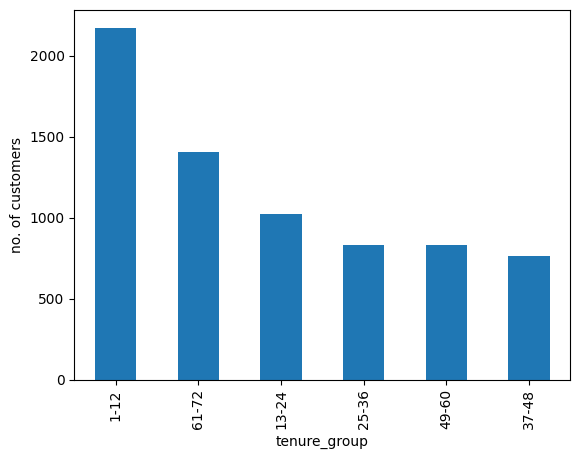

In [1164]:
df["tenure_group"].value_counts().plot(kind = "bar")
plt.ylabel("no. of customers")

In [1165]:
df.dtypes

customerID            object
gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
tenure                 int64
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
MonthlyCharges       float64
TotalCharges         float64
Churn                 object
tenure_group        category
dtype: object

Text(0.5, 1.0, 'Churn Distribution')

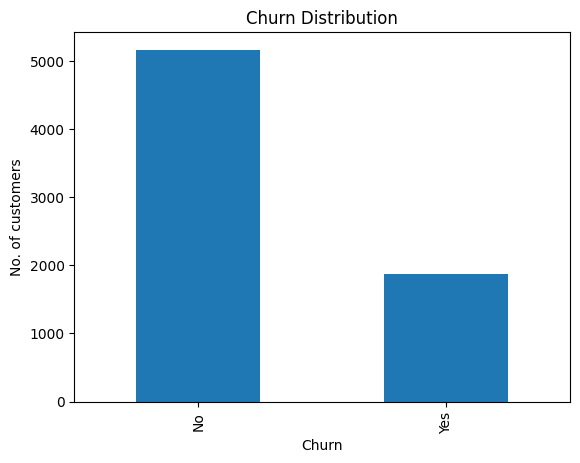

In [1166]:
df["Churn"].value_counts().plot(kind= "bar")
plt.ylabel("No. of customers")
plt.title("Churn Distribution")

In [1167]:
df_numeric= df.select_dtypes(include=['int64', 'float64']).corr()

<Axes: >

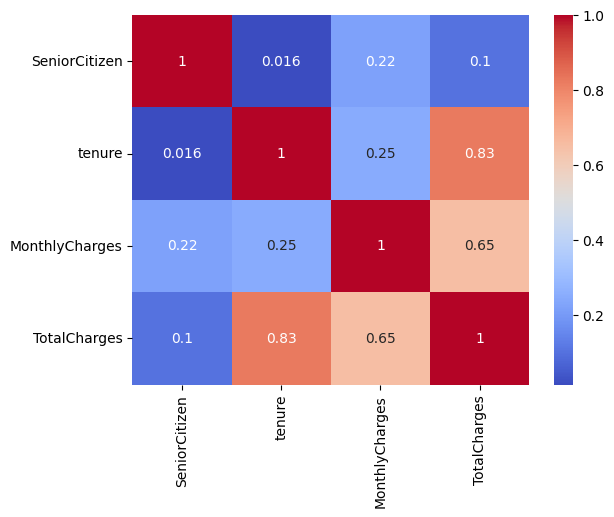

In [1168]:
sns.heatmap(df_numeric, annot=True, cmap='coolwarm')

In [1169]:
df_updated = df.drop(["customerID", "MonthlyCharges", "TotalCharges","tenure"] , axis=1)

In [1170]:
df_updated.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn,tenure_group
0,Female,0,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No,1-12
1,Male,0,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No,25-36
2,Male,0,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes,1-12
3,Male,0,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No,37-48
4,Female,0,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes,1-12


In [1171]:
df_updated.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn',
       'tenure_group'],
      dtype='object')

In [1172]:
df_updated.dtypes

gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
Churn                 object
tenure_group        category
dtype: object

In [1173]:
df_updated["Churn"] =df["Churn"].map({"Yes":1, "No":0})


In [1174]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group'],
      dtype='object')

In [1175]:
df['tenure_group'] = df["tenure_group"].astype(str)
df_updated.dtypes

gender                object
SeniorCitizen          int64
Partner               object
Dependents            object
PhoneService          object
MultipleLines         object
InternetService       object
OnlineSecurity        object
OnlineBackup          object
DeviceProtection      object
TechSupport           object
StreamingTV           object
StreamingMovies       object
Contract              object
PaperlessBilling      object
PaymentMethod         object
Churn                  int64
tenure_group        category
dtype: object

In [1176]:
df_dummies = pd.get_dummies(df_updated)

In [1177]:
df_dummies.head()

,SeniorCitizen,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-12,tenure_group_13-24,tenure_group_25-36,tenure_group_37-48,tenure_group_49-60,tenure_group_61-72
0,0,0,True,False,False,True,True,False,True,False,...,False,False,True,False,True,False,False,False,False,False
1,0,0,False,True,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,False,False
2,0,1,False,True,True,False,True,False,False,True,...,False,False,False,True,True,False,False,False,False,False
3,0,0,False,True,True,False,True,False,True,False,...,True,False,False,False,False,False,False,True,False,False
4,0,1,True,False,True,False,True,False,False,True,...,False,False,True,False,True,False,False,False,False,False


<Axes: >

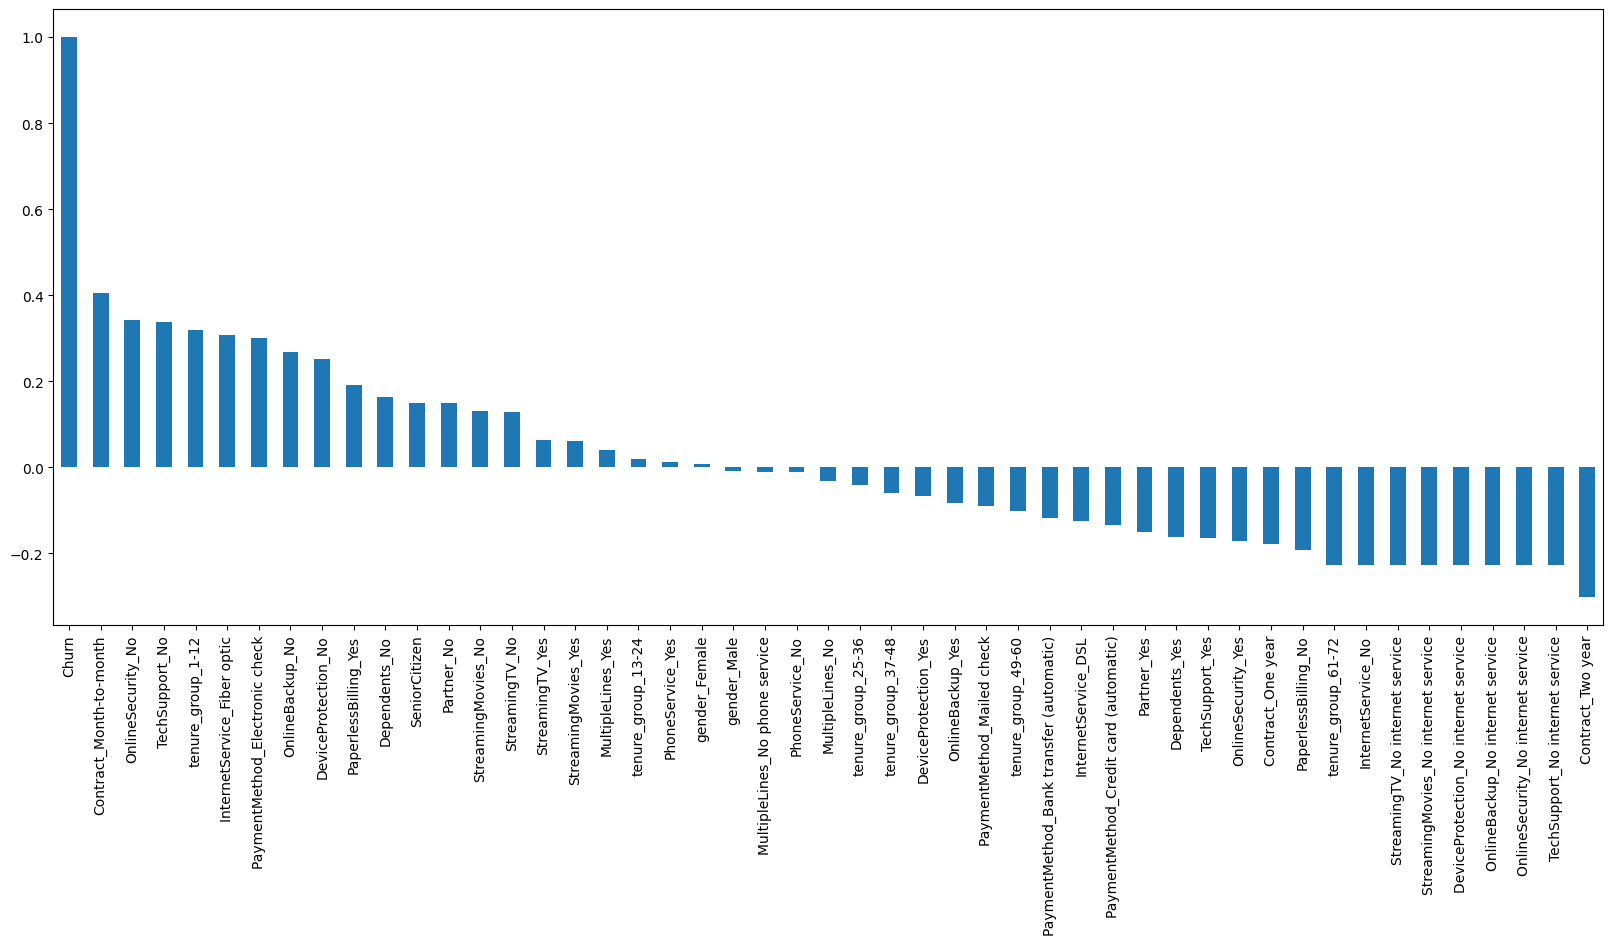

In [1178]:
df_dummies.corr()["Churn"].sort_values(ascending=False).plot(kind="bar", figsize = (20,8))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12,Low Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12,High Risk


In [1181]:
df.to_csv(r"C:\Users\angad\Desktop\telco2.csv")

MACHINE LEARNING/AI

In [1182]:
#MODELS

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import  RandomForestClassifier
from xgboost import XGBClassifier

In [1183]:
## Preprocessing

In [1184]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder


In [1185]:
##Metrics

In [1186]:
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [1187]:
##Explainability

In [1188]:
import shap

In [1189]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12,Low Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12,High Risk


In [1190]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [1191]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Segment
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,1-12,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.50,No,25-36,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1-12,Low Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,37-48,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1-12,High Risk


In [1192]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})
df["SeniorCitizen"] =df["SeniorCitizen"].map({1:"Yes", 0: "No"})

In [1193]:
new_df = df.drop(["customerID", "gender", "tenure", "Segment"], axis=1)

In [1194]:
new_df.head()

,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group
0,No,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12
1,No,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0,25-36
2,No,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12
3,No,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48
4,No,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12


In [1195]:
df_dummies= pd.get_dummies(new_df)

In [1196]:
df_dummies.head()

,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_No,SeniorCitizen_Yes,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,...,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure_group_1-12,tenure_group_13-24,tenure_group_25-36,tenure_group_37-48,tenure_group_49-60,tenure_group_61-72
0,29.85,29.85,0,True,False,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,False
1,56.95,1889.50,0,True,False,True,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2,53.85,108.15,1,True,False,True,False,True,False,False,...,False,False,False,True,True,False,False,False,False,False
3,42.30,1840.75,0,True,False,True,False,True,False,True,...,True,False,False,False,False,False,False,True,False,False
4,70.70,151.65,1,True,False,True,False,True,False,False,...,False,False,True,False,True,False,False,False,False,False


In [1197]:
df_dummies.columns

Index(['MonthlyCharges', 'TotalCharges', 'Churn', 'SeniorCitizen_No',
       'SeniorCitizen_Yes', 'Partner_No', 'Partner_Yes', 'Dependents_No',
       'Dependents_Yes', 'PhoneService_No', 'PhoneService_Yes',
       'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'Paperless

In [1198]:
X=df_dummies.drop(["Churn"], axis=1)
y=df_dummies["Churn"]

In [1199]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)

In [1200]:
#Feature Scaling

In [1201]:
from sklearn.compose import ColumnTransformer

In [1202]:
scaler= StandardScaler()

In [1203]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [1204]:
##Logistic Regression

In [1205]:
lr= LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,10000
,multi_class,'deprecated'


In [1206]:
y_train_pred_lr= lr.predict(X_train_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
y_pred_lr= (y_prob_lr >0.4).astype(int) 
#y_pred_lr= (y_prob_lr >0.3).astype(int) 

In [1207]:
print("Train:")
print(classification_report(y_train, y_train_pred_lr))

Train:
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      4130
           1       0.67      0.52      0.59      1495

    accuracy                           0.80      5625
   macro avg       0.76      0.71      0.73      5625
weighted avg       0.79      0.80      0.80      5625



In [1208]:
#Random Forest
rf= RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [1209]:
y_train_pred_rf= rf.predict(X_train)
#y_pred_rf= rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

y_pred_rf= (y_prob_rf >0.4).astype(int) 

In [1210]:
print('Train:')
print( classification_report(y_train, y_train_pred_rf))

Train:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4130
           1       1.00      1.00      1.00      1495

    accuracy                           1.00      5625
   macro avg       1.00      1.00      1.00      5625
weighted avg       1.00      1.00      1.00      5625



In [1211]:
#XGBoost
xgb =XGBClassifier( max_depth=4,
    learning_rate=0.05,
    n_estimators=1000,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.5,
    reg_lambda=5,
    min_child_weight=5,
    gamma=0.1)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [1212]:
y_train_pred_xgb= xgb.predict(X_train)
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [1213]:
print("Train:")
print(classification_report(y_train, y_train_pred_xgb))

Train:
              precision    recall  f1-score   support

           0       0.89      0.94      0.91      4130
           1       0.80      0.67      0.73      1495

    accuracy                           0.87      5625
   macro avg       0.84      0.81      0.82      5625
weighted avg       0.87      0.87      0.87      5625



In [1214]:
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n===== {model_name} =====")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))


# call
evaluate_model(y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_rf, y_prob_rf, "Random Forest")
evaluate_model(y_test, y_pred_xgb, y_prob_xgb, "XGBoost")


===== Logistic Regression =====
Accuracy: 0.7782515991471215
Precision: 0.5731132075471698
Recall: 0.6497326203208557
F1 Score: 0.6090225563909775
ROC-AUC: 0.8282661476101485

===== Random Forest =====
Accuracy: 0.7633262260127932
Precision: 0.5508684863523573
Recall: 0.5935828877005348
F1 Score: 0.5714285714285714
ROC-AUC: 0.8087769385673832

===== XGBoost =====
Accuracy: 0.7711442786069652
Precision: 0.5769230769230769
Recall: 0.5213903743315508
F1 Score: 0.547752808988764
ROC-AUC: 0.8157228569505774


In [1215]:
#Shap Feature Importance

In [1216]:
importances =lr.coef_[0]

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance)

                                    Feature  Importance
14              InternetService_Fiber optic    0.416338
34                  Contract_Month-to-month    0.386598
43                        tenure_group_1-12    0.320508
30                          StreamingTV_Yes    0.186830
33                      StreamingMovies_Yes    0.180852
12                        MultipleLines_Yes    0.127687
16                        OnlineSecurity_No    0.113790
41           PaymentMethod_Electronic check    0.107120
25                           TechSupport_No    0.096269
24                     DeviceProtection_Yes    0.093244
38                     PaperlessBilling_Yes    0.067809
19                          OnlineBackup_No    0.061538
6                             Dependents_No    0.048473
3                         SeniorCitizen_Yes    0.037938
21                         OnlineBackup_Yes    0.034205
9                          PhoneService_Yes    0.023331
4                                Partner_No    0

In [1217]:
X_train_scaled_ft = X_train_scaled.astype(float)
X_test_scaled_ft = X_test_scaled.astype(float)

In [1218]:
# SHAP
#explainer = shap.TreeExplainer(xgb)
explainer = shap.LinearExplainer(lr, X_train_scaled_ft)
shap_values = explainer.shap_values(X_test_scaled_ft)

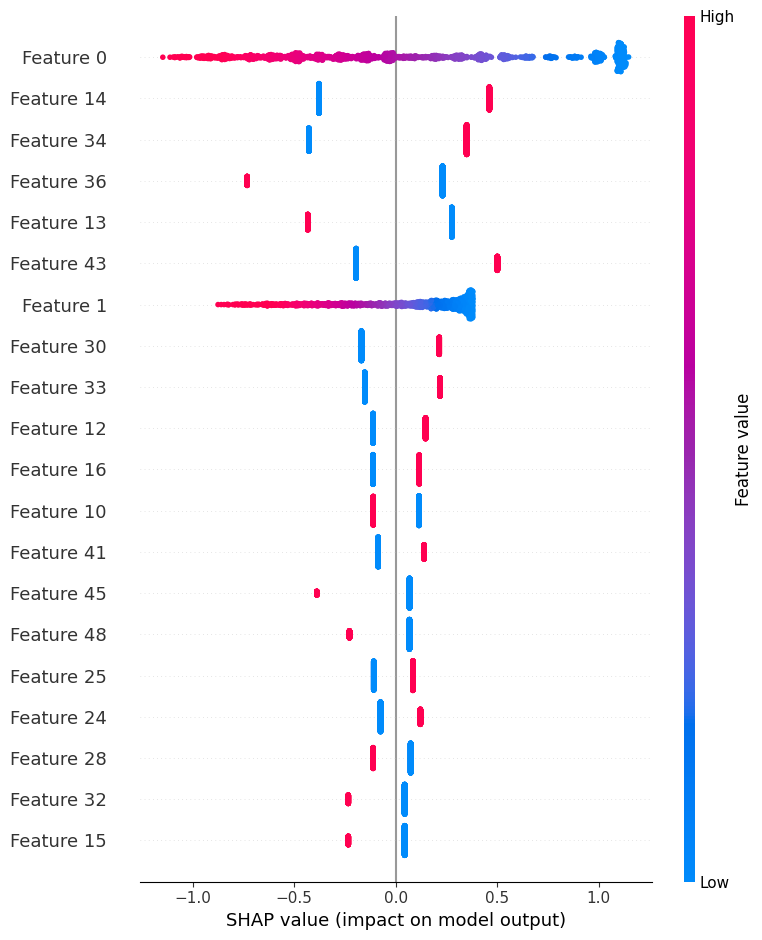

In [1219]:
shap.summary_plot(shap_values, X_test_scaled)

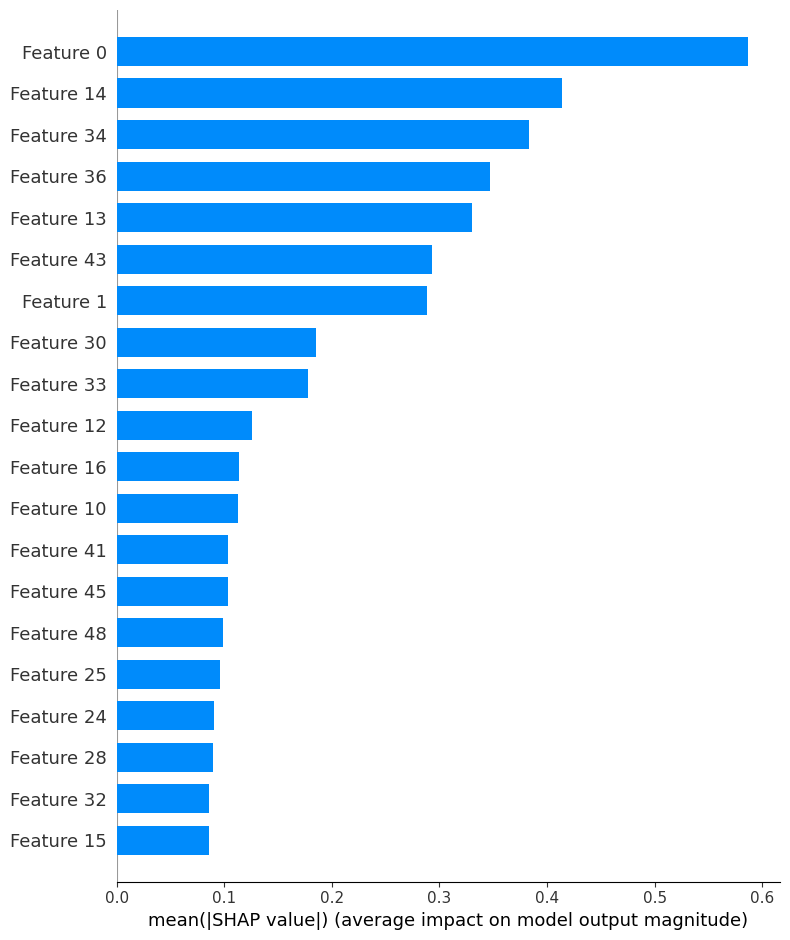

In [1220]:
shap.summary_plot(shap_values, X_test_scaled_ft, plot_type="bar" )

In [1221]:
X_scaled_full = scaler.transform(X)

In [1222]:
y_prob_full = lr.predict_proba(X_scaled_full)[:, 1]
y_pred_lr= (y_prob_lr >0.4).astype(int) 

In [1223]:
df['Churn_Risk_Probability'] = y_prob_full
df['Churn_Risk_%'] = df['Churn_Risk_Probability'] * 100

In [1225]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_group,Segment,Churn_Risk_Probability,Churn_Risk_%
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,0,1-12,High Risk,0.534226,53.422630
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,0,25-36,Low Risk,0.035985,3.598480
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,1,1-12,Low Risk,0.290042,29.004230
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,0,37-48,Low Risk,0.047799,4.779894
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,1,1-12,High Risk,0.698905,69.890456


In [1226]:
df.to_csv(r"C:\Users\angad\Desktop\telco_predicted.csv")